# Customer Churn Prediction

## Internship Project

### Objective

Predict whether a customer will churn using Machine Learning algorithms such as Logistic Regression and Random Forest.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

from sklearn.metrics import recall_score

from sklearn.metrics import roc_auc_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

from sklearn.metrics import RocCurveDisplay

In [2]:
df = pd.read_csv(r"C:\Users\manik\OneDrive\Desktop\Customer-Churn-Prediction\BankChurners.csv")

In [3]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
df.shape

(10127, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [7]:
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [9]:
df = df.drop(columns=[
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
])

In [10]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = encoder.fit_transform(df[col])

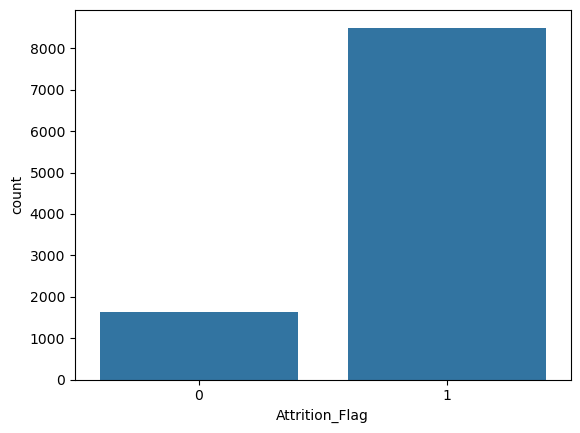

In [11]:
sns.countplot(x="Attrition_Flag", data=df)

plt.show()

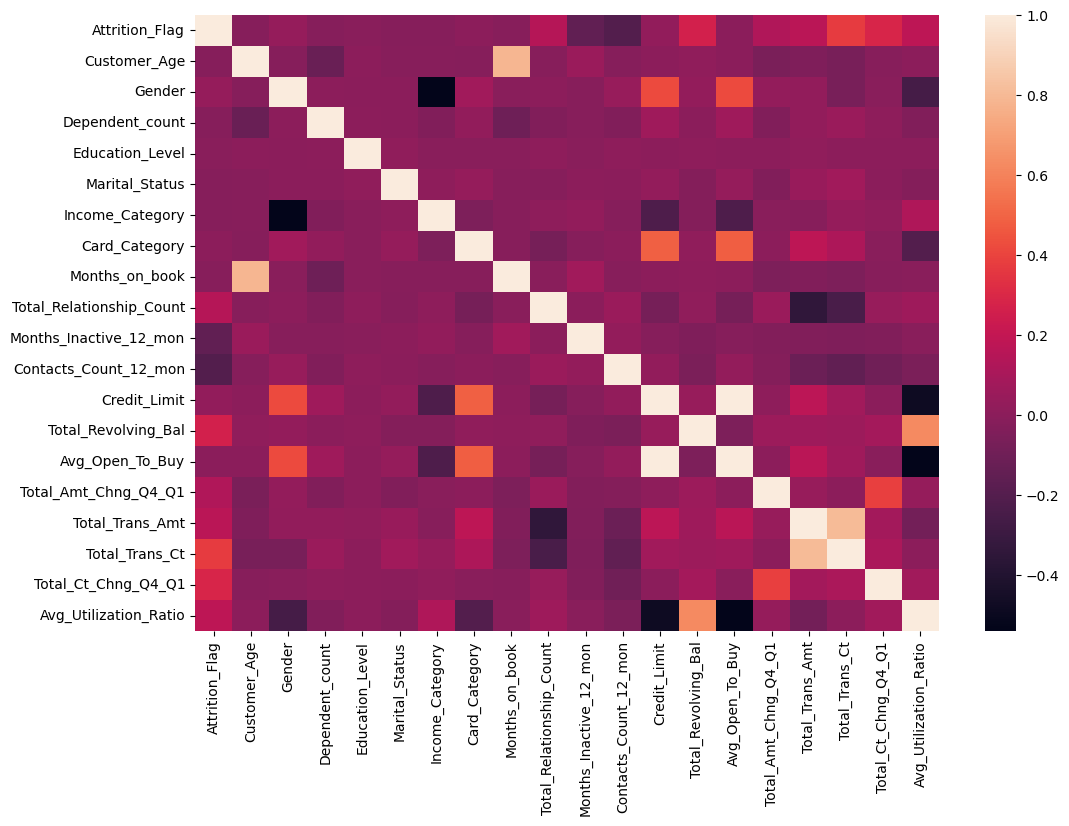

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr())

plt.show()

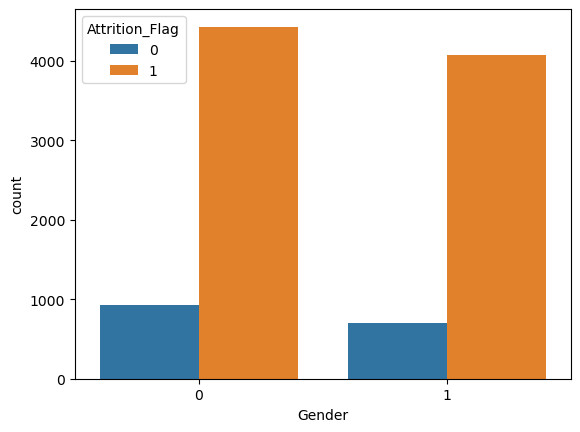

In [13]:
sns.countplot(
x="Gender",
hue="Attrition_Flag",
data=df
)

plt.show()

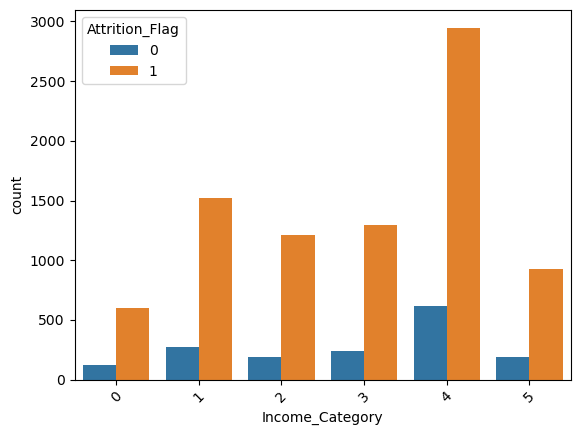

In [14]:
sns.countplot(
x="Income_Category",
hue="Attrition_Flag",
data=df
)

plt.xticks(rotation=45)

plt.show()

In [15]:
X = df.drop("Attrition_Flag", axis=1)

y = df["Attrition_Flag"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [18]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [19]:
pred_lr = lr.predict(X_test)

prob_lr = lr.predict_proba(X_test)[:,1]

In [20]:
print("Accuracy:",accuracy_score(y_test,pred_lr))

print("Recall:",recall_score(y_test,pred_lr))

print("ROC AUC:",roc_auc_score(y_test,prob_lr))

Accuracy: 0.8874629812438302
Recall: 0.9652736904061212
ROC AUC: 0.9013198985551854


In [21]:
rf = RandomForestClassifier(
n_estimators=300,
random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [22]:
pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

In [23]:
print("Accuracy:",accuracy_score(y_test,pred_rf))

print("Recall:",recall_score(y_test,pred_rf))

print("ROC AUC:",roc_auc_score(y_test,prob_rf))

Accuracy: 0.9570582428430404
Recall: 0.9876397881106533
ROC AUC: 0.9892894363116999


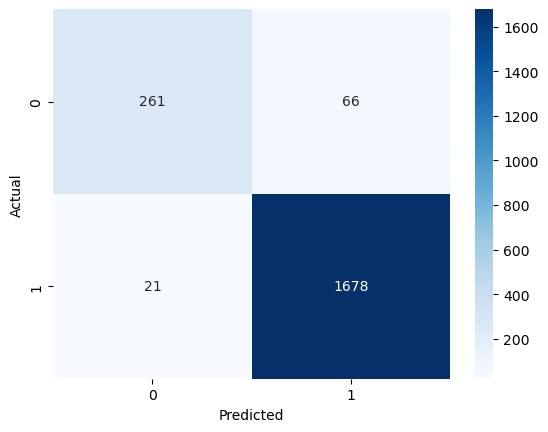

In [24]:
cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [25]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.80      0.86       327
           1       0.96      0.99      0.97      1699

    accuracy                           0.96      2026
   macro avg       0.94      0.89      0.92      2026
weighted avg       0.96      0.96      0.96      2026



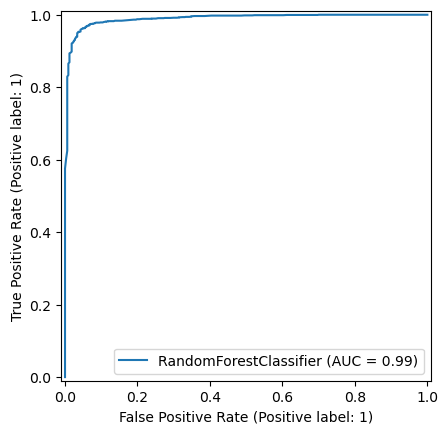

In [26]:
RocCurveDisplay.from_estimator(rf,X_test,y_test)

plt.show()

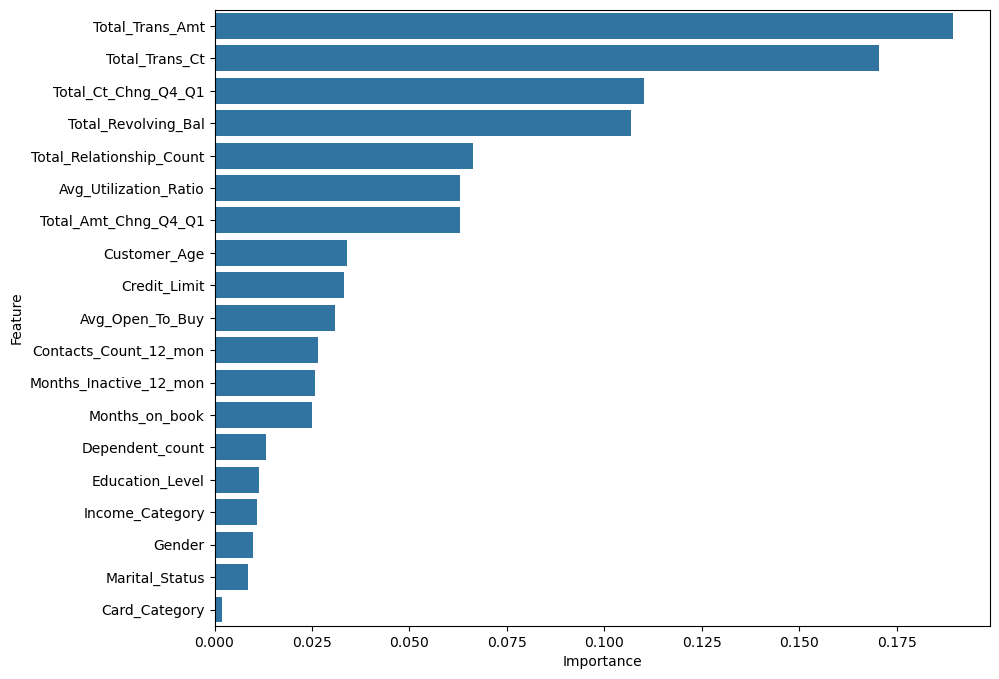

In [27]:
importance = pd.DataFrame({
"Feature":X.columns,
"Importance":rf.feature_importances_
})

importance = importance.sort_values(
by="Importance",
ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
x="Importance",
y="Feature",
data=importance
)

plt.show()

# Conclusion

- Performed data preprocessing and exploratory data analysis.
- Built Logistic Regression and Random Forest models.
- Evaluated the models using Accuracy, Recall, ROC-AUC, Confusion Matrix, and Classification Report.
- Random Forest achieved better performance and was selected as the final model.